# FFC U-Net 으로 잡음 제거 (파이프라인 1단계)

한 노트북에서 **두 조건**을 돌릴 수 있다. 셀 2의 `BLUR` 한 줄로 바뀐다.

| `BLUR` | 입력 → 정답 | 쓰임 |
|---|---|---|
| `False` | 원본 영상 + 잡음 → 원본 영상 | **1일차와 완전히 같은 조건.** Restormer 결과와 직접 비교 |
| `True` | 번진 영상 + 잡음 → 번진 영상 | **실제 파이프라인 1단계.** 오늘의 진짜 과제 |

`BLUR=False` 로 한 번 돌리면 "FFC 가 Restormer 보다 나은가"를 공정하게 비교할 수 있고,
`BLUR=True` 로 돌리면 파이프라인에 넣을 모델이 나온다.

## 참고 수치

**BLUR = False** (1일차 조건, test_noise_only)

| | PSNR | SSIM |
|---|---|---|
| 입력 | 24.671 | 0.6659 |
| 우리 Restormer | 35.677 | 0.9517 |

**BLUR = True** (오늘 조건, test_deconv_noise → test_deconv_only)

| | PSNR |
|---|---|
| 입력 | 18.51 |
| 3x3 중앙값 필터 | 22.17 |
| 주파수별 고정 필터 | 23.14 |


## 1. Drive 마운트 + 데이터 준비

In [13]:
from pathlib import Path

import torch
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/project5")     # TODO: 본인 경로
DATASET_ZIP = DRIVE_ROOT / "dataset.zip"

LOCAL_ROOT = Path("/content/work"); LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
NEEDED = ["train", "val", "test_label", "test_noise_only",
          "test_deconv_only", "test_deconv_noise"]

DECONV_ZIP = DRIVE_ROOT / "dataset_deconv.zip"   # 2일차에 추가된 폴더들


def still_missing():
    return [n for n in NEEDED if not any(LOCAL_ROOT.glob(f"{n}/**/*.npy"))]


if still_missing() and DATASET_ZIP.exists():
    !cp "{DATASET_ZIP}" /content/dataset.zip
    !unzip -q -o /content/dataset.zip -d "{LOCAL_ROOT}"

# 처음 받은 dataset.zip 에는 2일차 폴더가 없다. 따로 올린 zip 을 이어서 푼다.
if still_missing() and DECONV_ZIP.exists():
    !cp "{DECONV_ZIP}" /content/dataset_deconv.zip
    !unzip -q -o /content/dataset_deconv.zip -d "{LOCAL_ROOT}"

left = still_missing()
if left:
    raise FileNotFoundError(
        "아직 없는 폴더: " + str(left) + "  ->  " + str(DECONV_ZIP) + " 를 Drive 에 올릴 것. "
        "로컬 dataset 폴더에서 test_deconv_only / test_deconv_noise / test_deconv_multi "
        "세 개만 묶은 zip 이다 (약 79MB)."
    )


def find_npy_dir(base: Path) -> Path:
    """폴더가 한 겹 더 중첩된 경우까지 훑는다."""
    if any(base.glob("*.npy")):
        return base
    for sub in sorted(d for d in base.iterdir() if d.is_dir()):
        if any(sub.glob("*.npy")):
            return sub
    raise FileNotFoundError(base)


TRAIN_DIR = find_npy_dir(LOCAL_ROOT / "train")
VAL_DIR = find_npy_dir(LOCAL_ROOT / "val")
TEST_LABEL_DIR = find_npy_dir(LOCAL_ROOT / "test_label")
TEST_NOISE_DIR = find_npy_dir(LOCAL_ROOT / "test_noise_only")
TEST_DECONV_DIR = find_npy_dir(LOCAL_ROOT / "test_deconv_only")
TEST_DECONV_NOISE_DIR = find_npy_dir(LOCAL_ROOT / "test_deconv_noise")

for n, d in [("train", TRAIN_DIR), ("val", VAL_DIR),
             ("test_label", TEST_LABEL_DIR), ("test_noise_only", TEST_NOISE_DIR),
             ("test_deconv_only", TEST_DECONV_DIR), ("test_deconv_noise", TEST_DECONV_NOISE_DIR)]:
    print(f"  {n:20s} {len(list(d.glob('*.npy'))):5d}")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  train                 7268
  val                    100
  test_label             100
  test_noise_only        100
  test_deconv_only       100
  test_deconv_noise      100
GPU: NVIDIA A100-SXM4-80GB


## 2. 설정 — `BLUR` 한 줄로 조건이 바뀐다

In [14]:
import json, math, random, time, shutil
from dataclasses import dataclass, asdict

import numpy as np
import torch.nn.functional as F
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# ─────────────────────────────────────────────────────────
BLUR = True          # True: 번진 영상+잡음 → 번진 영상 (파이프라인 1단계)
                     # False: 원본 영상+잡음 → 원본 영상 (1일차 조건, Restormer 와 비교)
# ─────────────────────────────────────────────────────────

RUN_DIR = DRIVE_ROOT / ("logs_denoise_ffc_blur" if BLUR else "logs_denoise_ffc_plain")
RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT_LAST, CKPT_BEST = RUN_DIR / "checkpoint_last.ckpt", RUN_DIR / "checkpoint_best.ckpt"
HISTORY = RUN_DIR / "history.json"

LOCAL_CKPT = Path("/content/ckpt_dn"); LOCAL_CKPT.mkdir(parents=True, exist_ok=True)
LOCAL_LAST, LOCAL_BEST = LOCAL_CKPT / "last.ckpt", LOCAL_CKPT / "best.ckpt"
DRIVE_SYNC_EVERY = 10

NOISE_RANGES = {"gaussian": (0.0, 0.1), "rician": (0.0, 0.15),
                "uniform": (0.0, 0.2), "salt_and_pepper": (0.0, 0.2)}

# 잡음 종류를 뽑을 확률. rician 이 유독 약해(22.9 dB vs 나머지 31~34) 비중을 두 배로 준다.
# 검증·시험은 실제 구성대로 4종 균등이므로 여기만 바꾼다.
NOISE_WEIGHTS = {"gaussian": 0.20, "rician": 0.40,
                 "uniform": 0.20, "salt_and_pepper": 0.20}

# 손실 함수의 국소 평균 항. rician 은 밝기를 위로 미는 편향(+0.029)이 있는데
# L1 만으로는 이 편향과 무작위 오차를 구분하지 못한다. 창 크기별 평균을 맞춰 편향을 직접 벌한다.
MEAN_LOSS_SCALES = (8, 16, 32)
MEAN_LOSS_WEIGHT = 0.5
NUM_ORIENTATIONS, VAL_ORIENTATION, IMG_SIZE = 6, 3, 256


@dataclass
class FFCConfig:
    in_ch: int = 1
    out_ch: int = 1
    width: int = 48
    depth: int = 3
    n_blocks: int = 6
    ratio_g: float = 0.5


@dataclass
class TrainConfig:
    epochs: int = 200
    batch: int = 16
    lr: float = 3e-4
    lr_min: float = 1e-6
    weight_decay: float = 1e-4
    grad_clip: float = 0.5
    num_workers: int = 8
    val_batch: int = 8
    amp: bool = True
    seed: int = 0


model_cfg, train_cfg = FFCConfig(), TrainConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_dtype = torch.bfloat16 if train_cfg.amp else None
random.seed(train_cfg.seed); np.random.seed(train_cfg.seed); torch.manual_seed(train_cfg.seed)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("조건:", "번진 영상 + 잡음 → 번진 영상" if BLUR else "원본 영상 + 잡음 → 원본 영상")
print("저장:", RUN_DIR)


조건: 번진 영상 + 잡음 → 번진 영상
저장: /content/drive/MyDrive/project5/logs_denoise_ffc_blur


## 3. PSNR / SSIM — 실습 노트북과 동일 구현

In [15]:
class SSIMcal(torch.nn.Module):
    def __init__(self, win=11, k1=0.01, k2=0.03):
        super().__init__()
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win, win) / win**2)
        self.cov_norm = win**2 / (win**2 - 1)

    def forward(self, img, ref, dr):
        dr = dr[:, None, None, None]
        C1, C2 = (self.k1 * dr) ** 2, (self.k2 * dr) ** 2
        w = self.w.to(img.device)
        ux, uy = F.conv2d(img, w), F.conv2d(ref, w)
        uxx, uyy = F.conv2d(img * img, w), F.conv2d(ref * ref, w)
        uxy = F.conv2d(img * ref, w)
        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)
        A1, A2 = 2 * ux * uy + C1, 2 * vxy + C2
        B1, B2 = ux**2 + uy**2 + C1, vx + vy + C2
        return torch.mean((A1 * A2) / (B1 * B2), dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()
def calculate_ssim(img, ref):
    return ssim_cal.forward(img, ref, torch.ones(ref.shape[0], device=ref.device))
def calculate_psnr(img, ref):
    mse = torch.mean(F.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(torch.amax(ref, dim=(1, 2, 3), keepdim=True)**2 / (mse + 1e-12))


## 4. 다이폴 커널 · 잡음 생성기

잡음은 **정답 영상 위에** 얹는다. `BLUR=True` 면 정답이 번진 영상이므로
잡음도 번진 영상 위에 얹힌다 — 주최측이 `test_deconv_noise` 를 만든 방식과 같다.
(가우시안 실측 표준편차가 선언 sigma 와 일치하고, salt & pepper 의 흰 점 값이
번진 영상의 최댓값과 같은 것으로 확인했다.)


In [16]:
def dipole_kernel(matrix_size, voxel_size=(1.0, 1.0), B0_dir=(0.0, 1.0)) -> Tensor:
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)
    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])
    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    return torch.tensor(np.fft.fftshift(D), dtype=torch.float32)


ANGLES = [math.pi * i / NUM_ORIENTATIONS for i in range(NUM_ORIENTATIONS)]
KERNELS = torch.stack([dipole_kernel((IMG_SIZE, IMG_SIZE), (1.0, 1.0),
                                     (math.cos(a), math.sin(a))) for a in ANGLES])


def apply_dipole(img, kernel):
    return torch.fft.ifftn(torch.fft.fftn(img, dim=(-2, -1)) * kernel, dim=(-2, -1)).real


def gaussian_noise(img, s): return img + torch.randn_like(img) * s
def uniform_noise(img, s):  return img + (torch.rand_like(img) * 2.0 - 1.0) * s
def rician_noise(img, s):
    return torch.abs(img + torch.randn_like(img) * s + 1j * torch.randn_like(img) * s)
def salt_and_pepper_noise(img, s):
    out = img.clone(); num = int(img.numel() * s / 2)
    out[tuple(torch.randint(0, d, (num,)) for d in img.shape)] = img.max()
    out[tuple(torch.randint(0, d, (num,)) for d in img.shape)] = 0
    return out


NOISE_FUNCS = {"gaussian": gaussian_noise, "rician": rician_noise,
               "uniform": uniform_noise, "salt_and_pepper": salt_and_pepper_noise}
NOISE_NAMES = list(NOISE_RANGES)


def add_noise(img, seed=None, weighted=False):
    """weighted=True 면 NOISE_WEIGHTS 비율로 종류를 뽑는다 (학습 전용)."""
    rng = random if seed is None else random.Random(seed)
    if weighted:
        name = rng.choices(NOISE_NAMES, weights=[NOISE_WEIGHTS[n] for n in NOISE_NAMES])[0]
    else:
        name = rng.choice(NOISE_NAMES)
    lo, hi = NOISE_RANGES[name]
    sigma = rng.uniform(lo, hi)
    if seed is None:
        return NOISE_FUNCS[name](img, sigma)
    st = torch.random.get_rng_state(); torch.manual_seed(seed)
    try:
        out = NOISE_FUNCS[name](img, sigma)
    finally:
        torch.random.set_rng_state(st)
    return out


## 5. 데이터셋

In [17]:
import zlib


def load_npy(path: Path) -> Tensor:
    img = torch.from_numpy(np.load(str(path))).float()
    return img.unsqueeze(0) if img.dim() == 2 else img


class DenoiseDataset(Dataset):
    """정답 = (BLUR 면) 번진 영상, 아니면 원본 영상.  입력 = 정답 + 잡음."""

    def __init__(self, clean_dir: Path, training: bool):
        self.files = sorted(clean_dir.glob("*.npy"))
        self.training = training

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        clean = load_npy(path)
        if self.training:
            if random.random() < 0.5: clean = torch.flip(clean, dims=[1])
            if random.random() < 0.5: clean = torch.flip(clean, dims=[2])
            k = random.randint(0, 3)
            if k: clean = torch.rot90(clean, k, dims=[1, 2])
            clean = clean.contiguous()
            ori = random.randrange(NUM_ORIENTATIONS)
        else:
            ori = VAL_ORIENTATION

        target = apply_dipole(clean.unsqueeze(0), KERNELS[ori]).squeeze(0) if BLUR else clean
        seed = None if self.training else zlib.crc32(path.name.encode())
        noisy = add_noise(target, seed, weighted=self.training)
        return target, noisy, path.name


class PairedDataset(Dataset):
    """주최측이 준 (입력, 정답) 파일 짝을 그대로 쓴다."""

    def __init__(self, target_dir: Path, noisy_dir: Path):
        self.target_dir, self.noisy_dir = target_dir, noisy_dir
        self.names = sorted(p.name for p in target_dir.glob("*.npy"))

    def __len__(self): return len(self.names)

    def __getitem__(self, i):
        n = self.names[i]
        return load_npy(self.target_dir / n), load_npy(self.noisy_dir / n), n


train_loader = DataLoader(DenoiseDataset(TRAIN_DIR, True), batch_size=train_cfg.batch,
                          shuffle=True, drop_last=True, num_workers=train_cfg.num_workers,
                          pin_memory=True, persistent_workers=train_cfg.num_workers > 0)
val_loader = DataLoader(DenoiseDataset(VAL_DIR, False), batch_size=train_cfg.val_batch,
                        shuffle=False, num_workers=2, pin_memory=True)

TEST_TARGET = TEST_DECONV_DIR if BLUR else TEST_LABEL_DIR
TEST_INPUT = TEST_DECONV_NOISE_DIR if BLUR else TEST_NOISE_DIR
test_loader = DataLoader(PairedDataset(TEST_TARGET, TEST_INPUT),
                         batch_size=train_cfg.val_batch, shuffle=False,
                         num_workers=2, pin_memory=True)

_t, _n, _ = next(iter(test_loader))
print("steps per epoch:", len(train_loader))
print(f"테스트 입력 PSNR: {calculate_psnr(_n, _t).mean():.3f} dB")
print("  기대값:", "18.51 (BLUR=True)" if BLUR else "24.67 (BLUR=False)")


steps per epoch: 454
테스트 입력 PSNR: 19.283 dB
  기대값: 18.51 (BLUR=True)


## 6. FFC U-Net — 역합성곱 노트북과 동일 구조

In [18]:
class SpectralTransform(nn.Module):
    """FFT -> 1x1 합성곱 -> 역FFT. 주파수 성분을 직접 만진다."""

    def __init__(self, ch: int):
        super().__init__()
        self.pre = nn.Sequential(nn.Conv2d(ch, ch // 2, 1, bias=False),
                                 nn.BatchNorm2d(ch // 2), nn.ReLU(inplace=True))
        self.fu = nn.Sequential(nn.Conv2d(ch, ch, 1, bias=False),
                                nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
                                nn.Conv2d(ch, ch, 1, bias=False))
        self.post = nn.Conv2d(ch // 2, ch, 1, bias=False)

    def forward(self, x):
        b, c, h, w = x.shape
        y = self.pre(x)
        # FFT 계열은 bfloat16 을 받지 못한다. 이 구간만 32비트로 계산한다.
        with torch.autocast("cuda", enabled=False):
            ffted = torch.fft.rfftn(y.float(), dim=(-2, -1), norm="ortho")
            ffted = torch.cat([ffted.real, ffted.imag], dim=1)
            ffted = self.fu(ffted).float()
            r, i = ffted.chunk(2, dim=1)
            out = torch.fft.irfftn(torch.complex(r, i), s=(h, w), dim=(-2, -1), norm="ortho")
        return self.post(out.to(x.dtype))


class FFC(nn.Module):
    def __init__(self, in_ch, out_ch, ratio_g):
        super().__init__()
        self.in_g = int(in_ch * ratio_g) // 2 * 2
        self.in_l = in_ch - self.in_g
        self.out_g = int(out_ch * ratio_g) // 2 * 2
        self.out_l = out_ch - self.out_g
        cv = lambda i, o, k: nn.Conv2d(i, o, k, padding=k // 2, bias=False) if i and o else None
        self.l2l = cv(self.in_l, self.out_l, 3)
        self.l2g = cv(self.in_l, self.out_g, 3)
        self.g2l = cv(self.in_g, self.out_l, 3)
        self.g2g = SpectralTransform(self.out_g) if self.in_g and self.out_g else None
        self.g2g_in = cv(self.in_g, self.out_g, 1) if self.in_g and self.out_g else None

    def forward(self, x):
        xl, xg = x[:, :self.in_l], x[:, self.in_l:]
        ol = og = 0
        if self.l2l is not None: ol = ol + self.l2l(xl)
        if self.g2l is not None: ol = ol + self.g2l(xg)
        if self.l2g is not None: og = og + self.l2g(xl)
        if self.g2g is not None: og = og + self.g2g(self.g2g_in(xg))
        outs = [t for t in (ol, og) if torch.is_tensor(t)]
        return torch.cat(outs, dim=1) if len(outs) > 1 else outs[0]


class FFCBlock(nn.Module):
    def __init__(self, ch, ratio_g):
        super().__init__()
        self.c1, self.n1 = FFC(ch, ch, ratio_g), nn.BatchNorm2d(ch)
        self.c2, self.n2 = FFC(ch, ch, ratio_g), nn.BatchNorm2d(ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        y = self.act(self.n1(self.c1(x)))
        return self.act(x + self.n2(self.c2(y)))


class FFCUNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        w, rg = cfg.width, cfg.ratio_g
        self.head = nn.Sequential(nn.Conv2d(cfg.in_ch, w, 3, padding=1), nn.ReLU(inplace=True))
        chs = [w * (2 ** i) for i in range(cfg.depth + 1)]
        self.downs = nn.ModuleList([nn.Sequential(
            FFCBlock(chs[i], rg),
            nn.Conv2d(chs[i], chs[i + 1], 3, stride=2, padding=1), nn.ReLU(inplace=True))
            for i in range(cfg.depth)])
        self.mid = nn.Sequential(*[FFCBlock(chs[-1], rg) for _ in range(cfg.n_blocks)])
        self.ups = nn.ModuleList([nn.Sequential(
            nn.ConvTranspose2d(chs[i + 1], chs[i], 2, stride=2), nn.ReLU(inplace=True))
            for i in reversed(range(cfg.depth))])
        self.fuse = nn.ModuleList([nn.Conv2d(chs[i] * 2, chs[i], 1)
                                   for i in reversed(range(cfg.depth))])
        self.tail = nn.Conv2d(w, cfg.out_ch, 3, padding=1)

    def forward(self, x):
        y = self.head(x)
        skips = []
        for blk in self.downs:
            y_in = blk[0](y); skips.append(y_in)
            y = blk[2](blk[1](y_in))
        y = self.mid(y)
        for up, fu, sk in zip(self.ups, self.fuse, reversed(skips)):
            y = fu(torch.cat([up(y), sk], dim=1))
        # 잡음 제거는 입력과 출력이 거의 같으므로 전역 skip 을 쓴다
        return self.tail(y) + x


net = FFCUNet(model_cfg).to(device)
print(f"parameters: {sum(p.numel() for p in net.parameters())/1e6:.2f} M")
with torch.no_grad():
    print("shape check:", tuple(net(torch.randn(1, 1, 256, 256, device=device)).shape))


parameters: 15.84 M
shape check: (1, 1, 256, 256)


## 7. 학습

In [19]:
optimizer = torch.optim.AdamW(net.parameters(), lr=train_cfg.lr,
                              betas=(0.9, 0.999), weight_decay=train_cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=train_cfg.epochs, eta_min=train_cfg.lr_min)
l1 = nn.L1Loss()


def denoise_loss(pred, target):
    """L1 + 국소 평균 오차. 뒤쪽 항이 rician 의 밝기 편향을 정조준한다."""
    loss = l1(pred, target)
    for k in MEAN_LOSS_SCALES:
        loss = loss + MEAN_LOSS_WEIGHT * l1(F.avg_pool2d(pred, k), F.avg_pool2d(target, k))
    return loss


def save_ckpt(path, epoch, best):
    torch.save({"epoch": epoch, "best_psnr": best, "blur": BLUR,
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "model_config": asdict(model_cfg)}, path)


start_epoch, best_psnr, history = 0, -1.0, []
RESUME = LOCAL_LAST if LOCAL_LAST.exists() else CKPT_LAST
if RESUME.exists():
    ck = torch.load(RESUME, map_location=device, weights_only=False)
    if ck.get("blur") != BLUR:
        raise RuntimeError(f"체크포인트는 BLUR={ck.get('blur')} 로 학습된 것이다. "
                           "다른 조건으로 이어할 수 없다 — RUN_DIR 을 나눠 쓸 것.")
    net.load_state_dict(ck["model_state_dict"])
    optimizer.load_state_dict(ck["optimizer_state_dict"])
    scheduler.load_state_dict(ck["scheduler_state_dict"])
    start_epoch, best_psnr = ck["epoch"] + 1, ck["best_psnr"]
    if HISTORY.exists():
        history = json.loads(HISTORY.read_text())
    if scheduler.T_max != train_cfg.epochs or abs(scheduler.base_lrs[0] - train_cfg.lr) > 1e-12:
        scheduler.T_max = train_cfg.epochs
        scheduler.base_lrs = [train_cfg.lr] * len(scheduler.base_lrs)
        for g, b in zip(optimizer.param_groups, scheduler.base_lrs):
            g["lr"] = train_cfg.lr_min + (b - train_cfg.lr_min) * (
                1 + math.cos(math.pi * scheduler.last_epoch / scheduler.T_max)) / 2
        print("학습률 곡선 재계획")
    print(f"이어서 학습: epoch {start_epoch + 1} 부터, best val PSNR {best_psnr:.3f}")
else:
    print("처음부터 학습")


학습률 곡선 재계획
이어서 학습: epoch 121 부터, best val PSNR 30.220


In [20]:
def run_train_epoch(epoch):
    net.train(); total = count = 0
    pbar = tqdm(train_loader, desc=f"train ep {epoch+1}/{train_cfg.epochs}", leave=False)
    for target, noisy, _ in pbar:
        target, noisy = target.to(device, non_blocking=True), noisy.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                loss = denoise_loss(net(noisy), target)
        else:
            loss = denoise_loss(net(noisy), target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), train_cfg.grad_clip)
        optimizer.step()
        total += loss.item() * target.shape[0]; count += target.shape[0]
        pbar.set_postfix(loss=f"{total/count:.5f}")
    return total / count


@torch.no_grad()
def evaluate(loader):
    net.eval(); ps, ss = [], []
    for target, noisy, _ in tqdm(loader, desc="valid", leave=False):
        target, noisy = target.to(device), noisy.to(device)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                out = net(noisy)
            out = out.float()
        else:
            out = net(noisy)
        ps.append(calculate_psnr(out, target).flatten())
        ss.append(calculate_ssim(out, target).flatten())
    return torch.cat(ps).mean().item(), torch.cat(ss).mean().item()


DIVERGE_RATIO = 5.0
prev_loss = history[-1]["loss"] if history else None
t0 = time.time()

for epoch in range(start_epoch, train_cfg.epochs):
    train_loss = run_train_epoch(epoch)
    val_psnr, val_ssim = evaluate(val_loader)
    scheduler.step()

    if prev_loss is not None and train_loss > prev_loss * DIVERGE_RATIO:
        src = LOCAL_BEST if LOCAL_BEST.exists() else CKPT_BEST
        rescue = torch.load(src, map_location=device, weights_only=False)
        net.load_state_dict(rescue["model_state_dict"])
        optimizer.load_state_dict(rescue["optimizer_state_dict"])
        scheduler.base_lrs = [b * 0.5 for b in scheduler.base_lrs]
        for g, b in zip(optimizer.param_groups, scheduler.base_lrs):
            g["lr"] = train_cfg.lr_min + (b - train_cfg.lr_min) * (
                1 + math.cos(math.pi * scheduler.last_epoch / scheduler.T_max)) / 2
        print(f"ep {epoch+1:3d}  발산 감지 — best 로 되돌리고 학습률 {scheduler.base_lrs[0]:.2e}")
        continue

    prev_loss = train_loss
    is_best = val_psnr > best_psnr
    if is_best:
        best_psnr = val_psnr; save_ckpt(LOCAL_BEST, epoch, best_psnr)
    save_ckpt(LOCAL_LAST, epoch, best_psnr)

    if (epoch + 1) % DRIVE_SYNC_EVERY == 0 or epoch + 1 == train_cfg.epochs:
        try:
            shutil.copy2(LOCAL_LAST, CKPT_LAST)
            if LOCAL_BEST.exists(): shutil.copy2(LOCAL_BEST, CKPT_BEST)
        except Exception as err:
            print(f"        Drive 동기화 실패 (로컬 저장됨): {err}")

    history.append({"epoch": epoch + 1, "loss": train_loss, "val_psnr": val_psnr,
                    "val_ssim": val_ssim, "lr": optimizer.param_groups[0]["lr"]})
    try:
        HISTORY.write_text(json.dumps(history, indent=1))
    except OSError:
        pass

    print(f"ep {epoch+1:3d}/{train_cfg.epochs}  loss {train_loss:.5f}  "
          f"val PSNR {val_psnr:7.3f}  SSIM {val_ssim:.4f}  "
          f"[{(time.time()-t0)/60:.1f} min]{'  <- best' if is_best else ''}")

print(f"\n학습 종료. best val PSNR = {best_psnr:.3f}")


train ep 121/200:   0%|          | 0/454 [00:00<?, ?it/s]

valid:   0%|          | 0/13 [00:00<?, ?it/s]

ep 121/200  loss 0.01766  val PSNR  29.630  SSIM 0.8960  [1.8 min]


train ep 122/200:   0%|          | 0/454 [00:00<?, ?it/s]

valid:   0%|          | 0/13 [00:00<?, ?it/s]

...

valid:   0%|          | 0/13 [00:00<?, ?it/s]

ep 199/200  loss 0.01408  val PSNR  30.311  SSIM 0.9099  [90.1 min]


train ep 200/200:   0%|          | 0/454 [00:00<?, ?it/s]

valid:   0%|          | 0/13 [00:00<?, ?it/s]

ep 200/200  loss 0.01406  val PSNR  30.310  SSIM 0.9099  [91.3 min]

학습 종료. best val PSNR = 30.373


## 8. 테스트 — 잡음 종류별 표

`BLUR=False` 면 1일차 표와 같은 형식이라 Restormer·타 조 결과와 직접 비교된다.


In [21]:
best = torch.load(LOCAL_BEST if LOCAL_BEST.exists() else CKPT_BEST,
                  map_location=device, weights_only=False)
net.load_state_dict(best["model_state_dict"]); net.eval()
print(f"best checkpoint: epoch {best['epoch']+1}, val PSNR {best['best_psnr']:.3f}")


def mean_filter(x, k=3):
    p = k // 2
    return F.avg_pool2d(F.pad(x, (p,) * 4, mode="reflect"), kernel_size=k, stride=1)


def median_filter(x, k=3):
    p = k // 2
    xp = F.pad(x, (p,) * 4, mode="reflect")
    pt = xp.unfold(2, k, 1).unfold(3, k, 1)
    return pt.reshape(*pt.shape[:4], -1).median(dim=-1).values


meta_path = TEST_INPUT / "noise_meta.json"
lookup = {}
if meta_path.exists():
    lookup = {r["file"]: r["noise_type"] for r in json.loads(meta_path.read_text())}

METHODS = ["noisy", "ffc", "mean", "median"]
LAB = {"noisy": "입력", "ffc": "FFC U-Net", "mean": "Mean 3x3", "median": "Median 3x3"}
rows = []
with torch.no_grad():
    for target, noisy, names in tqdm(test_loader, desc="test"):
        target, noisy = target.to(device), noisy.to(device)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                pred = net(noisy)
            pred = pred.float()
        else:
            pred = net(noisy)
        outs = {"noisy": noisy, "ffc": pred,
                "mean": mean_filter(noisy), "median": median_filter(noisy)}
        for i in range(target.shape[0]):
            ref = target[i:i+1]
            row = {"file": names[i], "noise_type": lookup.get(names[i], "unknown")}
            for m in METHODS:
                row[f"psnr_{m}"] = calculate_psnr(outs[m][i:i+1], ref).item()
                row[f"ssim_{m}"] = calculate_ssim(outs[m][i:i+1], ref).item()
            rows.append(row)


def table(metric):
    fmt = ".3f" if metric == "psnr" else ".4f"
    print(f"\n[{metric.upper()}]   조건: {'번짐+잡음 → 번진 영상' if BLUR else '원본+잡음 → 원본'}")
    print(f"{'noise':<18}{'n':>4}" + "".join(f"{LAB[m]:>14}" for m in METHODS))
    print("-" * (22 + 14 * len(METHODS)))
    for nz in [*NOISE_NAMES, "unknown"]:
        sub = [r for r in rows if r["noise_type"] == nz]
        if not sub: continue
        print(f"{nz:<18}{len(sub):>4}" +
              "".join(f"{np.mean([r[f'{metric}_{m}'] for r in sub]):>14{fmt}}" for m in METHODS))
    print("-" * (22 + 14 * len(METHODS)))
    print(f"{'ALL':<18}{len(rows):>4}" +
          "".join(f"{np.mean([r[f'{metric}_{m}'] for r in rows]):>14{fmt}}" for m in METHODS))


table("psnr"); table("ssim")
mine = np.mean([r["psnr_ffc"] for r in rows])
if BLUR:
    print(f"\n참고: 입력 18.51 / 중앙값 22.17 / 주파수 고정필터 23.14  →  차이 {mine-23.14:+.2f} dB")
else:
    print(f"\n참고: 우리 Restormer 35.677  →  차이 {mine-35.677:+.2f} dB")
(RUN_DIR / "test_metrics.json").write_text(json.dumps(rows, indent=1))


best checkpoint: epoch 195, val PSNR 30.373


test:   0%|          | 0/13 [00:00<?, ?it/s]


[PSNR]   조건: 번짐+잡음 → 번진 영상
noise                n            입력     FFC U-Net      Mean 3x3    Median 3x3
------------------------------------------------------------------------------
gaussian            25        19.953        31.029        22.801        22.627
rician              25        14.557        23.229        17.024        16.900
uniform             25        22.295        31.610        23.499        22.445
salt_and_pepper     25        17.223        35.198        22.359        26.698
------------------------------------------------------------------------------
ALL                100        18.507        30.266        21.421        22.167

[SSIM]   조건: 번짐+잡음 → 번진 영상
noise                n            입력     FFC U-Net      Mean 3x3    Median 3x3
------------------------------------------------------------------------------
gaussian            25        0.5693        0.9506        0.7857        0.7494
rician              25        0.4581        0.8519        0.6435        0.6

37011

## 9. 결과 이미지

한글 폰트: 없음 — 영문 라벨로 표시한다


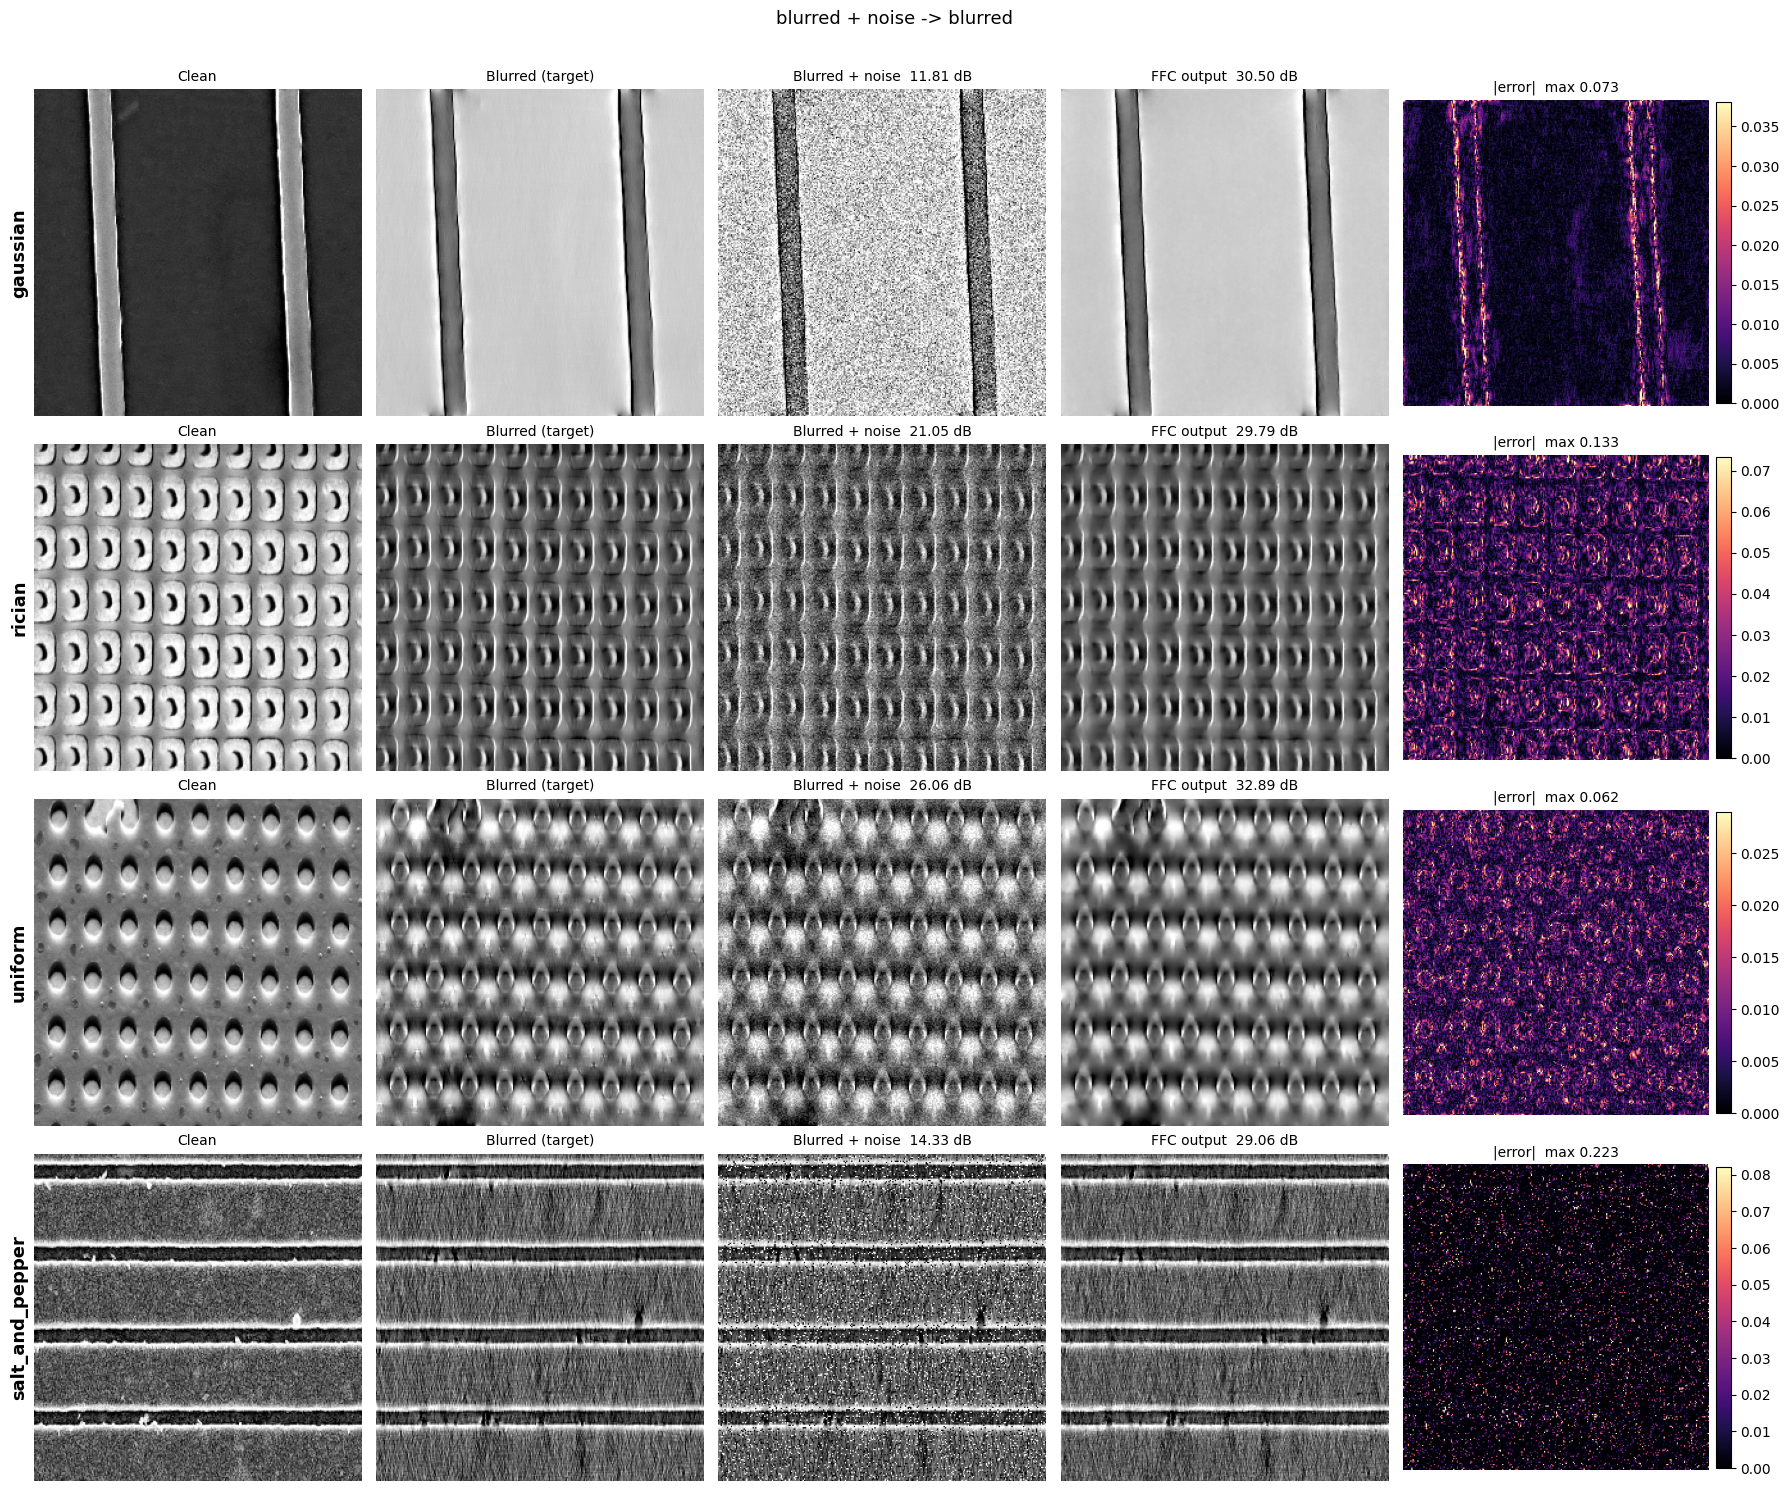

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab 기본 이미지에는 한글 폰트가 없어 글자가 네모로 나온다. 한 번만 설치하면 된다.
if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
    !apt-get -qq install -y fonts-nanum > /dev/null 2>&1
    fm._load_fontmanager(try_read_cache=False)

KO = ""
for cand in ("NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic"):
    if any(f.name == cand for f in fm.fontManager.ttflist):
        KO = cand
        break
if KO:
    plt.rcParams["font.family"] = KO
plt.rcParams["axes.unicode_minus"] = False      # 음수 부호가 네모로 나오는 것 방지
print("한글 폰트:", KO or "없음 — 영문 라벨로 표시한다")


def L(ko, en):
    return ko if KO else en

# 잡음 4종류가 각각 한 장씩 나오도록 고른다 (첫 배치만 쓰면 종류가 치우친다)
want = list(NOISE_NAMES) if lookup else ["unknown"]
picked = {}
for nm in sorted(p.name for p in TEST_TARGET.glob("*.npy")):
    t = lookup.get(nm, "unknown")
    if t in want and t not in picked:
        picked[t] = nm
    if len(picked) == len(want):
        break
rows_sel = [(t, picked[t]) for t in want if t in picked]

target = torch.stack([load_npy(TEST_TARGET / nm) for _, nm in rows_sel]).to(device)
noisy = torch.stack([load_npy(TEST_INPUT / nm) for _, nm in rows_sel]).to(device)
names = [nm for _, nm in rows_sel]
row_labels = [t for t, _ in rows_sel]
with torch.no_grad():
    pred = net(noisy).float()

# 원본 영상은 test_label 에서 이름으로 찾아 온다 (BLUR 이면 정답이 번진 영상이므로 따로 필요)
clean = torch.stack([load_npy(TEST_LABEL_DIR / n) for n in names]).to(device)

n = target.shape[0]
n_cols = 5 if BLUR else 4

fig, axes = plt.subplots(n, n_cols, figsize=(3.6 * n_cols, 3.8 * n))
axes = np.asarray(axes).reshape(n, n_cols)

for r in range(n):
    ref = target[r:r+1]
    c_np = clean[r, 0].cpu().numpy()
    t_np = target[r, 0].cpu().numpy()
    err = np.abs(pred[r, 0].cpu().numpy() - t_np)

    cv = (float(np.percentile(c_np, 1)), float(np.percentile(c_np, 99)))   # 원본용 밝기 범위
    tv = (float(np.percentile(t_np, 1)), float(np.percentile(t_np, 99)))   # 번진 영상용 밝기 범위

    if BLUR:
        panels = [
            (c_np, L("원본 영상", "Clean"), "gray", cv),
            (t_np, L("번진 영상 (정답)", "Blurred (target)"), "gray", tv),
            (noisy[r, 0].cpu().numpy(),
             f'{L("번짐 + 잡음", "Blurred + noise")}  {calculate_psnr(noisy[r:r+1], ref).item():.2f} dB', "gray", tv),
            (pred[r, 0].cpu().numpy(),
             f'{L("FFC 결과", "FFC output")}  {calculate_psnr(pred[r:r+1], ref).item():.2f} dB', "gray", tv),
            (err, f'{L("|오차|  최대", "|error|  max")} {err.max():.3f}', "magma",
             (0.0, float(np.percentile(err, 99.5)))),
        ]
    else:
        panels = [
            (c_np, L("원본 영상 (정답)", "Clean (target)"), "gray", cv),
            (noisy[r, 0].cpu().numpy(),
             f'{L("원본 + 잡음", "Clean + noise")}  {calculate_psnr(noisy[r:r+1], ref).item():.2f} dB', "gray", cv),
            (pred[r, 0].cpu().numpy(),
             f'{L("FFC 결과", "FFC output")}  {calculate_psnr(pred[r:r+1], ref).item():.2f} dB', "gray", cv),
            (err, f'{L("|오차|  최대", "|error|  max")} {err.max():.3f}', "magma",
             (0.0, float(np.percentile(err, 99.5)))),
        ]

    for c, (img, ttl, cmap, (vmin, vmax)) in enumerate(panels):
        im = axes[r, c].imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[r, c].set_title(ttl, fontsize=10)
        if c == 0:
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
            for sp in axes[r, c].spines.values():
                sp.set_visible(False)
            axes[r, c].set_ylabel(row_labels[r], fontsize=13, fontweight="bold")
        else:
            axes[r, c].axis("off")
    fig.colorbar(im, ax=axes[r, -1], fraction=0.046, pad=0.02)

fig.suptitle(L("번짐 + 잡음 → 번진 영상", "blurred + noise -> blurred") if BLUR
             else L("원본 + 잡음 → 원본 영상", "clean + noise -> clean"), fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(RUN_DIR / "denoise_grid.png", dpi=140, bbox_inches="tight")
plt.show()

## 10. 참고 — 잡음 제거 뒤에 고전적 역합성곱을 붙이면

**제출용이 아니다.** 1단계가 만든 결과가 뒷단에서 어느 정도 성적으로 이어지는지
대략 보기 위한 계기판이다. 위너 필터는 최종 과제에 쓸 수 없고, TKD 도 규칙 확인 전이다.

비교 대상을 네 줄로 둔다.

| 줄 | 뜻 |
|---|---|
| 잡음 없는 번진 영상 | **상한선.** 1단계가 완벽했다면 |
| **FFC 결과 → 역합성곱** | **지금 우리 파이프라인** |
| 잡음 제거 없이 바로 | 1단계를 건너뛰었을 때 |
| 입력 그대로 | 아무것도 안 했을 때 |


In [23]:
# 최종 지표는 원본 영상(test_label) 과 비교한다
assert BLUR, "이 셀은 BLUR=True 조건에서만 의미가 있다"

Dk = KERNELS[VAL_ORIENTATION].to(device)          # B0=(0,1) — forward_meta 와 동일
sgn = torch.where(Dk >= 0, 1.0, -1.0)


def tkd_inverse(img, thr):
    safe = torch.where(Dk.abs() < thr, sgn * thr, Dk)
    return torch.fft.ifftn(torch.fft.fftn(img, dim=(-2, -1)) / safe, dim=(-2, -1)).real


def wiener_inverse(img, K):
    num = torch.fft.fftn(img, dim=(-2, -1)) * Dk
    return torch.fft.ifftn(num / (Dk**2 + K), dim=(-2, -1)).real


# 1단계 출력을 한 번만 만들어 재사용한다
den, blur_clean, noisy_all, clean_all = [], [], [], []
net.eval()
with torch.no_grad():
    for target, noisy, names in tqdm(test_loader, desc="1단계 통과"):
        target, noisy = target.to(device), noisy.to(device)
        if amp_dtype is not None:
            with torch.autocast("cuda", dtype=amp_dtype):
                out = net(noisy)
            out = out.float()
        else:
            out = net(noisy)
        den.append(out); blur_clean.append(target); noisy_all.append(noisy)
        clean_all.append(torch.stack([load_npy(TEST_LABEL_DIR / n) for n in names]).to(device))
den = torch.cat(den); blur_clean = torch.cat(blur_clean)
noisy_all = torch.cat(noisy_all); clean_all = torch.cat(clean_all)


def sweep(src, label):
    """여러 설정 중 가장 좋은 것을 골라 보여준다."""
    best = None
    for name, fn, params in (("TKD", tkd_inverse, (0.05, 0.1, 0.15, 0.2, 0.3, 0.45)),
                             ("Wiener", wiener_inverse, (1e-4, 1e-3, 3e-3, 1e-2, 3e-2))):
        for prm in params:
            with torch.no_grad():
                rec = fn(src, prm)
                ps = calculate_psnr(rec, clean_all).mean().item()
                ss = calculate_ssim(rec, clean_all).mean().item()
            if best is None or ps > best[0]:
                best = (ps, ss, f"{name} {prm:g}")
    print(f"  {label:<28}{best[0]:>9.2f} dB{best[1]:>10.4f}   ({best[2]})")
    return best


print("
최종 지표 — 원본 영상(test_label) 과 비교
")
print(f"  {'무엇을 역합성곱했나':<28}{'PSNR':>12}{'SSIM':>10}   (최적 설정)")
print("  " + "-" * 62)
sweep(blur_clean, "잡음 없는 번진 영상 (상한)")
sweep(den,        "FFC 결과  <- 우리 파이프라인")
sweep(noisy_all,  "잡음 제거 없이 바로")
print("  " + "-" * 62)
print(f"  {'입력 그대로 (아무것도 안 함)':<28}"
      f"{calculate_psnr(noisy_all, clean_all).mean().item():>9.2f} dB"
      f"{calculate_ssim(noisy_all, clean_all).mean().item():>10.4f}")
print(f"
  참고: 1단계 성적(번진 영상 대비) {calculate_psnr(den, blur_clean).mean().item():.2f} dB")

SyntaxError: unterminated string literal (detected at line 52) (1875181707.py, line 52)